In [45]:
import pandas as pd
import numpy as np


In [47]:
# Keep the 2024-onwards data as the working dataset
df_new = pd.read_csv("data/lahore_aqi_historical_2024_onwards.csv")


In [48]:
df_new

,timestamp,temperature,humidity,wind_speed,pressure,modeled_pm25,modeled_pm10,ground_pm25,hour,day_of_week,month
0,2024-01-01 00:00:00,6.2,99,3.4,992.7,260.8,375.3,141.436667,0,0,1
1,2024-01-01 01:00:00,6.1,98,2.3,992.6,260.8,375.3,128.845000,1,0,1
2,2024-01-01 02:00:00,6.4,99,2.2,992.6,239.3,344.6,131.483333,2,0,1
3,2024-01-01 03:00:00,6.2,100,3.1,992.7,208.6,299.0,140.615000,3,0,1
4,2024-01-01 04:00:00,6.6,97,3.1,992.5,196.0,281.3,142.643333,4,0,1
...,...,...,...,...,...,...,...,...,...,...,...
22651,2026-08-01 19:00:00,31.1,81,0.3,973.7,47.0,49.1,55.600000,19,5,8
22652,2026-08-01 20:00:00,30.4,85,2.8,974.2,51.6,53.6,45.714286,20,5,8
22653,2026-08-01 21:00:00,29.8,86,4.4,975.0,55.6,57.5,45.242857,21,5,8
22654,2026-08-01 22:00:00,29.4,88,4.9,975.3,57.0,58.8,45.328571,22,5,8


In [49]:
# Remove rows with missing values in the working dataframe
df_new = df_new.dropna(inplace=True)


In [53]:
df_new.isnull().sum()

AttributeError: 'NoneType' object has no attribute 'isnull'

In [4]:
df.describe()

,temperature,humidity,wind_speed,pressure,modeled_pm25,modeled_pm10,ground_pm25,hour,day_of_week,month
count,13680.000000,13680.000000,13680.000000,13680.000000,13680.000000,13680.000000,10101.000000,13680.00000,13680.000000,13680.000000
mean,24.575183,61.144444,5.903560,983.140402,68.489320,98.981615,111.182848,11.50000,3.000000,5.587719
std,8.669613,24.222973,3.546575,6.887347,50.243385,80.898645,104.497283,6.92244,1.995682,3.249981
min,3.300000,5.000000,0.000000,967.200000,3.400000,3.600000,0.313840,0.00000,0.000000,1.000000
25%,17.800000,41.000000,3.400000,977.300000,34.700000,49.200000,39.500000,5.75000,1.000000,3.000000
50%,26.000000,64.000000,5.300000,983.050000,53.000000,76.100000,61.035479,11.50000,3.000000,5.000000
75%,31.000000,82.000000,7.800000,988.900000,85.000000,123.400000,158.939986,17.25000,5.000000,8.000000
max,46.500000,100.000000,28.600000,1001.700000,353.900000,890.300000,527.131390,23.00000,6.000000,12.000000


In [5]:
df.isnull().sum()

timestamp          0
temperature        0
humidity           0
wind_speed         0
pressure           0
modeled_pm25       0
modeled_pm10       0
ground_pm25     3579
hour               0
day_of_week        0
month              0
dtype: int64

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")


In [ ]:
# Impute missing values in the target column if any remain
df_new[["ground_pm25"]] = imputer.fit_transform(df_new[["ground_pm25"]])
df = df_new.copy()
data = df.copy()


In [37]:
df_new.isnull().sum()

timestamp       0
temperature     0
humidity        0
wind_speed      0
pressure        0
modeled_pm25    0
modeled_pm10    0
ground_pm25     0
hour            0
day_of_week     0
month           0
dtype: int64

In [9]:
data.isnull().sum()

timestamp       0
temperature     0
humidity        0
wind_speed      0
pressure        0
modeled_pm25    0
modeled_pm10    0
ground_pm25     0
hour            0
day_of_week     0
month           0
dtype: int64

In [ ]:
data.describe()

,temperature,humidity,wind_speed,pressure,modeled_pm25,modeled_pm10,ground_pm25,hour,day_of_week,month
count,13680.000000,13680.000000,13680.000000,13680.000000,13680.000000,13680.000000,13680.000000,13680.00000,13680.000000,13680.000000
mean,24.575183,61.144444,5.903560,983.140402,68.489320,98.981615,98.063153,11.50000,3.000000,5.587719
std,8.669613,24.222973,3.546575,6.887347,50.243385,80.898645,92.457897,6.92244,1.995682,3.249981
min,3.300000,5.000000,0.000000,967.200000,3.400000,3.600000,0.313840,0.00000,0.000000,1.000000
25%,17.800000,41.000000,3.400000,977.300000,34.700000,49.200000,45.443445,5.75000,1.000000,3.000000
50%,26.000000,64.000000,5.300000,983.050000,53.000000,76.100000,61.035479,11.50000,3.000000,5.000000
75%,31.000000,82.000000,7.800000,988.900000,85.000000,123.400000,103.174302,17.25000,5.000000,8.000000
max,46.500000,100.000000,28.600000,1001.700000,353.900000,890.300000,527.131390,23.00000,6.000000,12.000000


In [10]:
df.duplicated().sum()

np.int64(0)

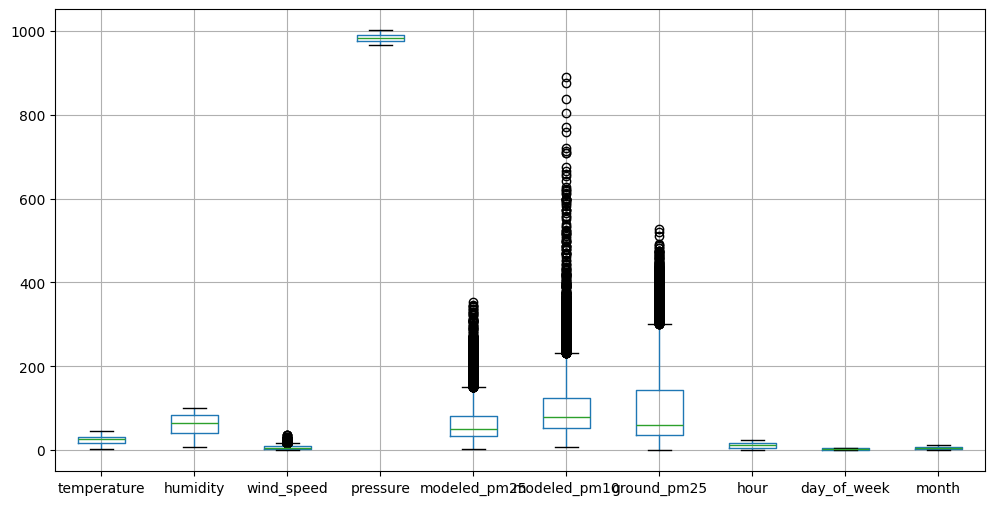

In [54]:
import matplotlib.pyplot as plt

df_new.boxplot(figsize=(12,6))
plt.show()

In [ ]:
# Use numeric_only=True to ignore the timestamp text column
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

print(IQR)


temperature     13.300000
humidity        39.000000
wind_speed       4.800000
pressure        11.900000
modeled_pm25    49.950000
modeled_pm10    74.700000
ground_pm25     33.798438
hour            11.500000
day_of_week      4.000000
month            6.000000
dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

feature_cols = [
    col for col in df_new.columns
    if col not in ['timestamp', 'ground_pm25'] and pd.api.types.is_numeric_dtype(df_new[col])
]

# Ensure all feature columns are numeric before scaling
for col in feature_cols:
    df_new[col] = pd.to_numeric(df_new[col], errors='coerce')

# Fit scaler on the same feature columns used for training
# and keep the target column unchanged

df_scale = df_new.copy()
df_scale[feature_cols] = scaler.fit_transform(df_new[feature_cols])


In [ ]:
X = df_scale[feature_cols]
y = df_scale["ground_pm25"]


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
df.head(5)

,timestamp,temperature,humidity,wind_speed,pressure,modeled_pm25,modeled_pm10,ground_pm25,hour,day_of_week,month
0,2025-01-01 00:00:00,7.4,100,3.5,994.2,319.4,323.2,61.035479,0,2,1
1,2025-01-01 01:00:00,7.7,100,4.2,994.0,302.7,306.4,61.035479,1,2,1
2,2025-01-01 02:00:00,7.4,100,4.6,993.5,262.6,266.4,61.035479,2,2,1
3,2025-01-01 03:00:00,7.6,100,4.1,993.1,233.8,237.5,61.035479,3,2,1
4,2025-01-01 04:00:00,7.3,100,2.3,992.4,220.7,224.0,61.035479,4,2,1


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)


In [ ]:
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
y_pred = rf_model.predict(X_test)


In [28]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.20365669240523832
RMSE: 0.30553348205719466
R²  : 0.9096984406518327


In [29]:
# --- 3. XGBOOST REGRESSOR ---
from xgboost import XGBRegressor
import time

start_time = time.time()
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time
print(f"XGBoost trained in {xgb_time:.2f} seconds")

XGBoost trained in 2.21 seconds


In [30]:
# --- 4. LIGHTGBM REGRESSOR ---
# Usually faster and slightly more accurate for tabular time series
import lightgbm as lgb

start_time = time.time()
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)
lgb_time = time.time() - start_time
print(f"LightGBM trained in {lgb_time:.2f} seconds")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1404
[LightGBM] [Info] Number of data points in the train set: 11540, number of used features: 9
[LightGBM] [Info] Start training from score -0.009078
LightGBM trained in 2.87 seconds


In [31]:
# --- 5. EVALUATION METRICS ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # MAPE calculation (safeguard against division by zero)
    mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1e-6))) * 100
    r2 = r2_score(y_test, y_pred)
    
    print(f"==== {name} Results ====")
    print(f"MAE  : {mae:.2f} µg/m³ (Average error)")
    print(f"RMSE : {rmse:.2f} µg/m³ (Penalizes large spikes)")
    print(f"MAPE : {mape:.2f}% (Percentage error)")
    print(f"R²   : {r2:.4f}")
    print()

evaluate_model("XGBoost", xgb_model, X_test, y_test)
evaluate_model("LightGBM", lgb_model, X_test, y_test)

==== XGBoost Results ====
MAE  : 0.22 µg/m³ (Average error)
RMSE : 0.32 µg/m³ (Penalizes large spikes)
MAPE : 9654995.35% (Percentage error)
R²   : 0.9027

==== LightGBM Results ====
MAE  : 0.21 µg/m³ (Average error)
RMSE : 0.31 µg/m³ (Penalizes large spikes)
MAPE : 9229291.49% (Percentage error)
R²   : 0.9095



C:\Users\Rana Zain Waseem\AppData\Local\Temp\ipykernel_10328\1266948443.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


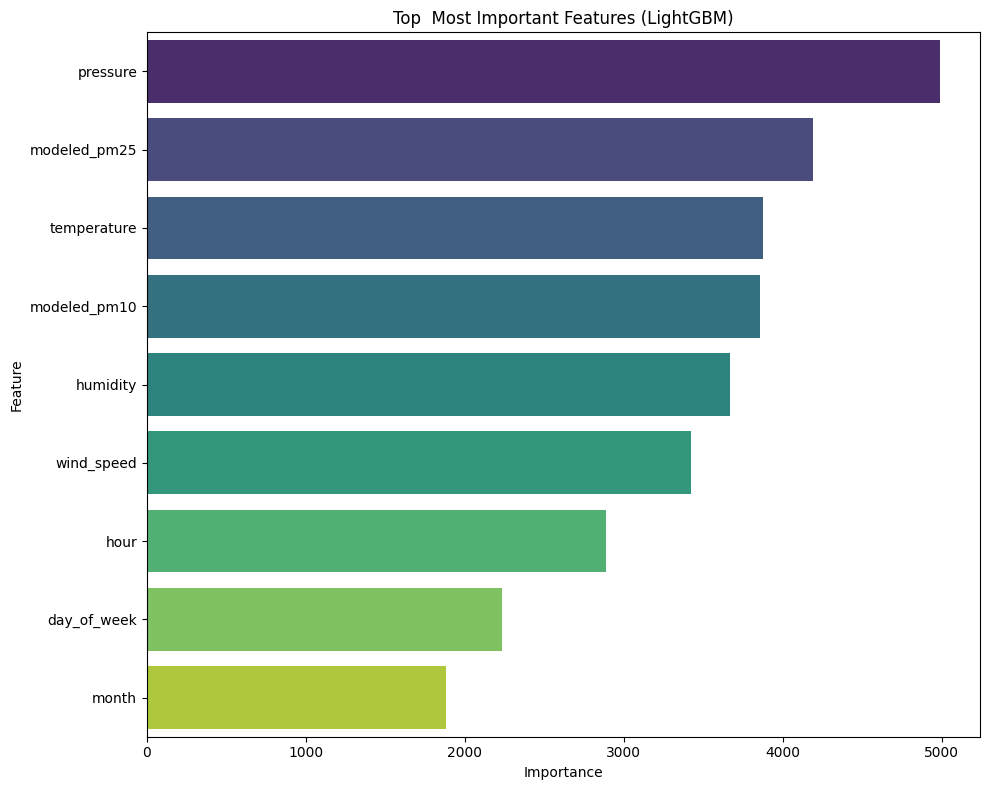

In [35]:
# --- 6. FEATURE IMPORTANCE (LightGBM) ---
import matplotlib.pyplot as plt
import seaborn as sns

importance = lgb_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top  Most Important Features (LightGBM)')
plt.tight_layout()
plt.show()



In [38]:
# --- 7. 72-HOUR FORECASTING ---
# Create a simple future feature table for the next 72 hours.
# In a real deployment, these values should come from weather forecasts and modeled AQI estimates.

future_hours = 72
last_timestamp = pd.to_datetime(df_new['timestamp'].max())

future_index = pd.date_range(start=last_timestamp + pd.Timedelta(hours=1), periods=future_hours, freq='h')

future_df = pd.DataFrame({
    'timestamp': future_index,
    'temperature': [df_new['temperature'].mean()] * future_hours,
    'humidity': [df_new['humidity'].mean()] * future_hours,
    'wind_speed': [df_new['wind_speed'].mean()] * future_hours,
    'pressure': [df_new['pressure'].mean()] * future_hours,
    'modeled_pm25': [df_new['modeled_pm25'].mean()] * future_hours,
    'modeled_pm10': [df_new['modeled_pm10'].mean()] * future_hours,
})

future_df['hour'] = future_df['timestamp'].dt.hour
future_df['day_of_week'] = future_df['timestamp'].dt.dayofweek
future_df['month'] = future_df['timestamp'].dt.month

# Keep the same column order as training data
future_features = future_df[feature_cols].copy()

# Make sure future features have the same dtypes as the training data
for col in feature_cols:
    future_features[col] = pd.to_numeric(future_features[col], errors='coerce')

# Scale future features with the same scaler used for training
future_scaled = scaler.transform(future_features)

# Predict next 72 hours of PM2.5 values
future_predictions = rf_model.predict(future_scaled)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'timestamp': future_df['timestamp'],
    'predicted_ground_pm25': future_predictions
})

print('--- 72-Hour AQI Forecast Preview ---')
print(forecast_df.head(10))


NameError: name 'feature_cols' is not defined